In [29]:
import sys
import torch

sys.path.append('..')

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.test_functions.MultivariateNormal import MultivariateNormal
from PySESM.base_functions.Function import GaussianFunctions

In [30]:
n_samples = 1000
n_features = 2
l_functions = 15

In [31]:
mu_1 = torch.tensor([1, 1])
mu_2 = torch.tensor([1, -1])
mu_3 = torch.tensor([-1, -1])

sigma_1 = 0.15 * torch.eye(2)
sigma_2 = 0.2 * torch.eye(2)
sigma_3 = 0.3 * torch.eye(2)

means = [mu_1, mu_2, mu_3]
covariances = [sigma_1, sigma_2, sigma_3]
scale_factors = [1.0, .5, 1.5]

In [32]:
mvn_1 = MultivariateNormal(n_features, means, covariances, scale_factors)

In [33]:
X, y = mvn_1.sample_n(n_samples)

print(X.shape)
print(y.shape)

torch.Size([1000, 2])
torch.Size([1000])


In [34]:
gaussian_function = GaussianFunctions(n_features=n_features, n_functions=l_functions)

In [35]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [36]:
model_epochs = 30
ista_epochs = 100   
dictionary_epochs = 60

ista_alpha = 0.02
ista_lambd = 0.001

dictionary_alpha = 0.02

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)

Epoch 1 Loss: 2.4967896938323975



Epoch 2 Loss: 0.3631190061569214

Epoch 3 Loss: 0.1107785776257515

Epoch 4 Loss: 0.057818684726953506

Epoch 5 Loss: 0.04062560200691223

Epoch 6 Loss: 0.032124485820531845

Epoch 7 Loss: 0.026709847152233124

Epoch 8 Loss: 0.02280251309275627

Epoch 9 Loss: 0.01978699490427971

Epoch 10 Loss: 0.01736416295170784

Epoch 11 Loss: 0.015374078415334225

Epoch 12 Loss: 0.01372942142188549

Epoch 13 Loss: 0.012347378768026829

Epoch 14 Loss: 0.011165937408804893

Epoch 15 Loss: 0.010151472873985767

Epoch 16 Loss: 0.009276852011680603

Epoch 17 Loss: 0.008519692346453667

Epoch 18 Loss: 0.007861354388296604

Epoch 19 Loss: 0.007286296226084232

Epoch 20 Loss: 0.006781518924981356

Epoch 21 Loss: 0.0063361539505422115

Epoch 22 Loss: 0.005941164679825306

Epoch 23 Loss: 0.005593444220721722

Epoch 24 Loss: 0.005291053093969822

Epoch 25 Loss: 0.005018311087042093

Epoch 26 Loss: 0.00477084144949913

Epoch 27 Loss: 0.004545080941170454

Epoch 28 Loss: 0.004338101949542761

Epoch 29 Loss: 0.0

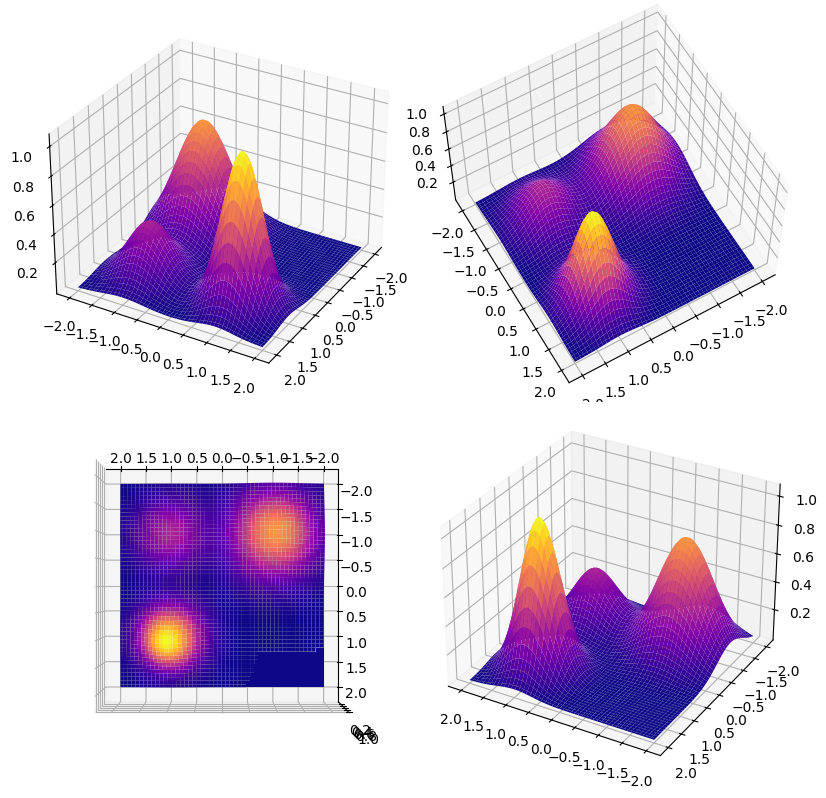

In [37]:
mvn_1.plot()

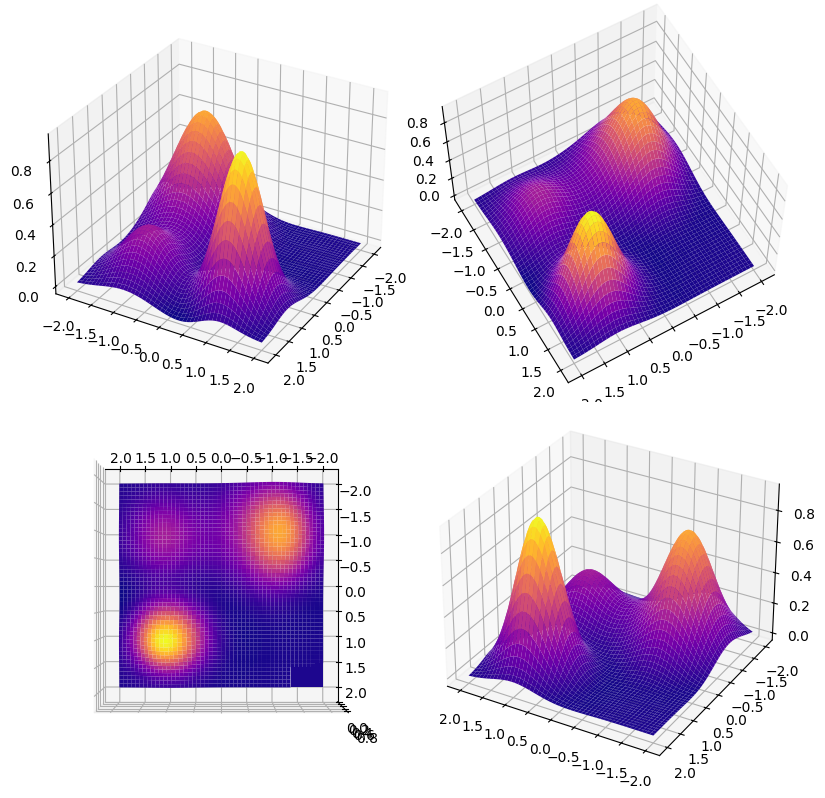

In [38]:
model.plot_function()

In [39]:
print(f'Duración del modelo: {model.time / 60:.2f} minutos')

Duración del modelo: 0.30 minutos


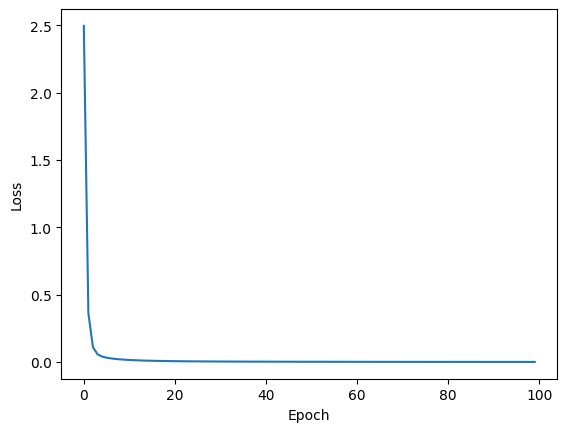

In [40]:
model.plot_loss()